# Week 2 — Exploratory Data Analysis (EDA)
## Supply Chain Intelligence Project

**Input:** `cleaned_supply_chain.csv` (from Week 1)  
**Output:** 10+ Plotly charts saved to `../outputs/`

### Objectives
1. Revenue trends over time
2. Late delivery analysis — by region, shipping mode, category
3. Top markets and product categories
4. Order volume patterns (monthly, quarterly)
5. Profit analysis
6. Delivery delay distribution
7. Customer segment overview
8. Cancellation analysis
9. Correlation heatmap
10. Key business KPIs summary

---
## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)

# ── Load clean data ────────────────────────────────────────────
df = pd.read_csv('../data/processed/cleaned_supply_chain.csv', parse_dates=['Order Date', 'Ship Date'])

print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
print(f'Date range: {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
df.head(3)

Rows    : 180,519
Columns : 49
Date range: 2015-01-01 → 2018-01-31


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,...,Revenue,Revenue_At_Risk,Order_Year,Order_Month,Order_Quarter,Order_DayOfWeek,Order_WeekOfYear,Is_Weekend,Order_YearMonth,Is_Cancelled
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,...,327.75,0.00,2018,1,1,2,5,0,2018-01,0
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,...,327.75,327.75,2018,1,1,5,2,1,2018-01,0
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,...,327.75,0.00,2018,1,1,5,2,1,2018-01,0


---
## 2. KPI Dashboard — Business Summary

In [2]:
total_revenue    = df['Revenue'].sum()
total_orders     = df['Order Date'].count()
late_rate        = df['Is_Late'].mean() * 100
cancel_rate      = df['Is_Cancelled'].mean() * 100
avg_delay        = df['Delivery_Delay_Days'].mean()
revenue_at_risk  = df['Revenue_At_Risk'].sum()
avg_profit       = df['Order Profit Per Order'].mean() if 'Order Profit Per Order' in df.columns else 0
total_categories = df['Category Name'].nunique() if 'Category Name' in df.columns else 0

print('=' * 55)
print('  SUPPLY CHAIN — KEY BUSINESS KPIs')
print('=' * 55)
print(f'  Total Revenue        : ${total_revenue:>12,.0f}')
print(f'  Total Orders         : {total_orders:>12,}')
print(f'  Late Delivery Rate   : {late_rate:>11.1f}%')
print(f'  Cancellation Rate    : {cancel_rate:>11.1f}%')
print(f'  Avg Delay (days)     : {avg_delay:>12.2f}')
print(f'  Revenue At Risk      : ${revenue_at_risk:>12,.0f}')
print(f'  Avg Profit/Order     : ${avg_profit:>12.2f}')
print(f'  Product Categories   : {total_categories:>12}')
print('=' * 55)

  SUPPLY CHAIN — KEY BUSINESS KPIs
  Total Revenue        : $  36,784,735
  Total Orders         :      180,519
  Late Delivery Rate   :        54.8%
  Cancellation Rate    :         2.0%
  Avg Delay (days)     :         0.57
  Revenue At Risk      : $  20,126,395
  Avg Profit/Order     : $       21.97
  Product Categories   :           50


---
## Chart 1 — Monthly Revenue Trend

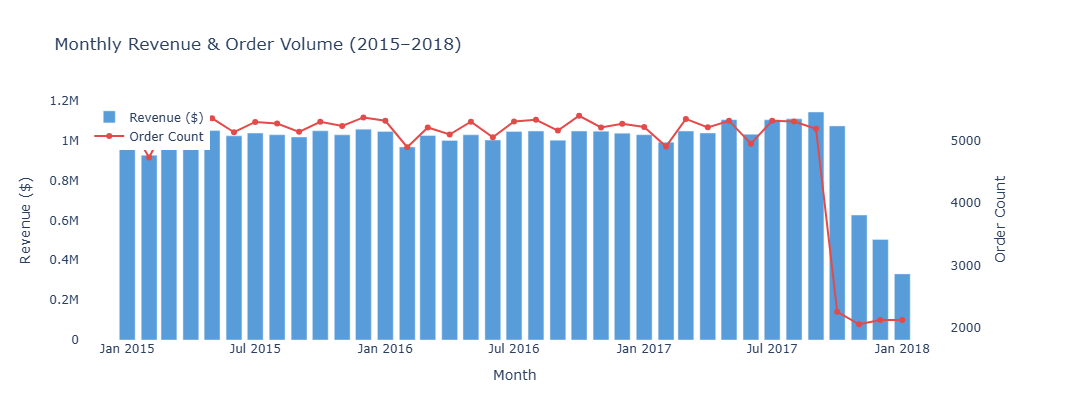

Chart 1 saved ✓


In [3]:
monthly_rev = df.groupby('Order_YearMonth').agg(
    Revenue = ('Revenue', 'sum'),
    Orders  = ('Revenue', 'count')
).reset_index()

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=monthly_rev['Order_YearMonth'], y=monthly_rev['Revenue'],
           name='Revenue ($)', marker_color='#3B8BD4', opacity=0.85),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=monthly_rev['Order_YearMonth'], y=monthly_rev['Orders'],
               name='Order Count', line=dict(color='#E24B4A', width=2), mode='lines+markers'),
    secondary_y=True
)

fig.update_layout(
    title='Monthly Revenue & Order Volume (2015–2018)',
    xaxis_title='Month',
    legend=dict(x=0.01, y=0.99),
    plot_bgcolor='white',
    height=420
)
fig.update_yaxes(title_text='Revenue ($)', secondary_y=False)
fig.update_yaxes(title_text='Order Count', secondary_y=True)
fig.write_html('../outputs/chart1_monthly_revenue.html')
fig.show()
print('Chart 1 saved ✓')

---
## Chart 2 — Late Delivery Rate by Shipping Mode

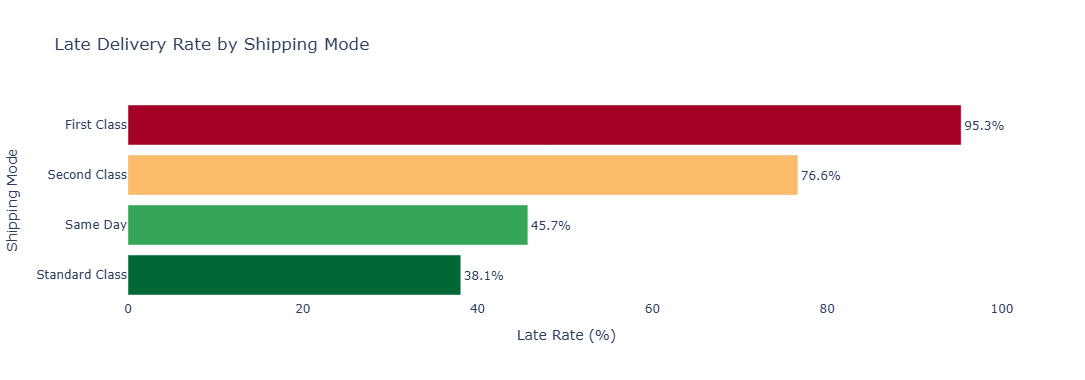

Chart 2 saved ✓

Detailed breakdown:
 Shipping Mode  Late_Rate_Pct  Avg_Delay  Order_Count
Standard Class      38.071683  -0.004093       107752
      Same Day      45.743042   0.478279         9737
  Second Class      76.632781   1.990828        35216
   First Class      95.322499   1.000000        27814


In [4]:
late_ship = df.groupby('Shipping Mode').agg(
    Late_Rate   = ('Is_Late', 'mean'),
    Avg_Delay   = ('Delivery_Delay_Days', 'mean'),
    Order_Count = ('Is_Late', 'count')
).reset_index().sort_values('Late_Rate', ascending=True)

late_ship['Late_Rate_Pct'] = late_ship['Late_Rate'] * 100

fig = px.bar(
    late_ship, x='Late_Rate_Pct', y='Shipping Mode',
    orientation='h',
    color='Late_Rate_Pct',
    color_continuous_scale='RdYlGn_r',
    text='Late_Rate_Pct',
    title='Late Delivery Rate by Shipping Mode',
    labels={'Late_Rate_Pct': 'Late Rate (%)', 'Shipping Mode': 'Shipping Mode'}
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(plot_bgcolor='white', height=380, coloraxis_showscale=False)
fig.write_html('../outputs/chart2_late_by_shipping.html')
fig.show()
print('Chart 2 saved ✓')

print('\nDetailed breakdown:')
print(late_ship[['Shipping Mode', 'Late_Rate_Pct', 'Avg_Delay', 'Order_Count']].to_string(index=False))

---
## Chart 3 — Revenue & Late Rate by Market

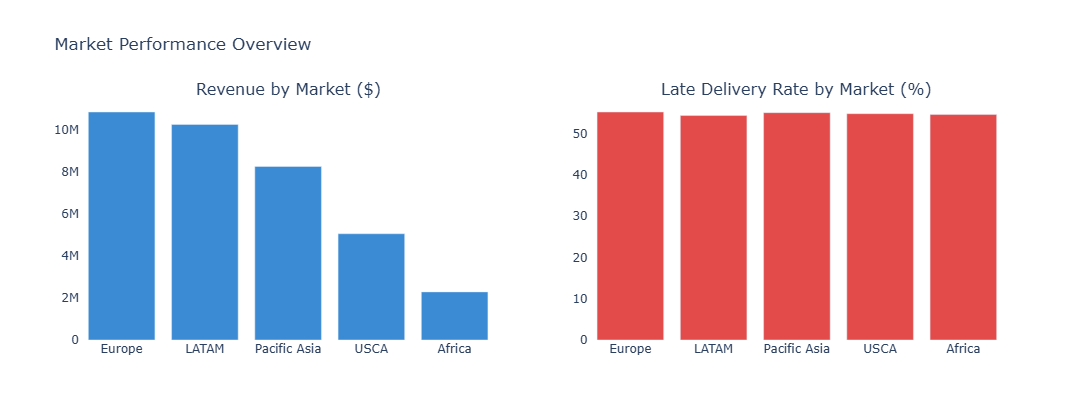

Chart 3 saved ✓


In [5]:
if 'Market' in df.columns:
    market_stats = df.groupby('Market').agg(
        Revenue   = ('Revenue', 'sum'),
        Late_Rate = ('Is_Late', 'mean'),
        Orders    = ('Revenue', 'count')
    ).reset_index().sort_values('Revenue', ascending=False)

    market_stats['Late_Rate_Pct'] = market_stats['Late_Rate'] * 100

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=('Revenue by Market ($)', 'Late Delivery Rate by Market (%)')
    )

    fig.add_trace(
        go.Bar(x=market_stats['Market'], y=market_stats['Revenue'],
               marker_color='#3B8BD4', name='Revenue'),
        row=1, col=1
    )
    fig.add_trace(
        go.Bar(x=market_stats['Market'], y=market_stats['Late_Rate_Pct'],
               marker_color='#E24B4A', name='Late Rate %'),
        row=1, col=2
    )

    fig.update_layout(title='Market Performance Overview', plot_bgcolor='white',
                      height=420, showlegend=False)
    fig.write_html('../outputs/chart3_market_analysis.html')
    fig.show()
    print('Chart 3 saved ✓')

---
## Chart 4 — Top 10 Product Categories by Revenue

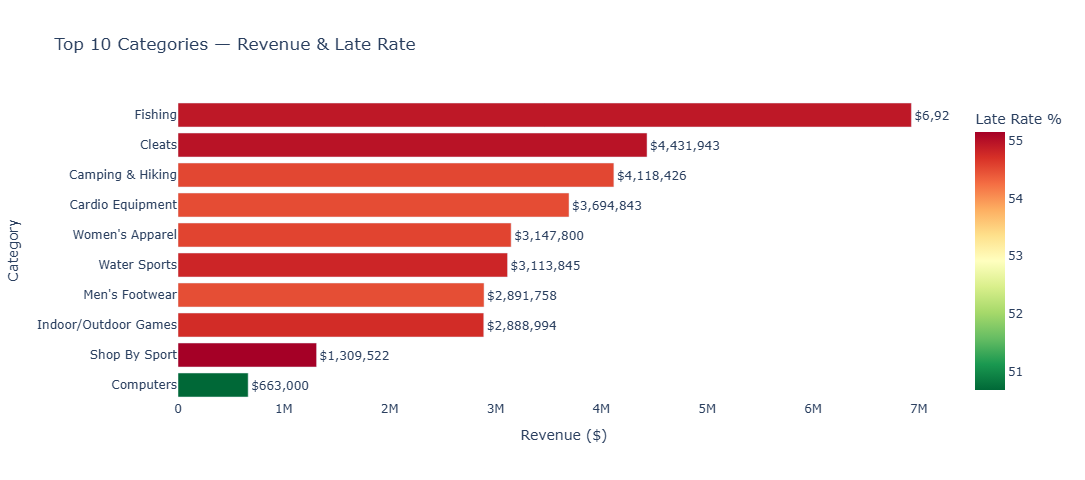

Chart 4 saved ✓


In [6]:
if 'Category Name' in df.columns:
    cat_stats = df.groupby('Category Name').agg(
        Revenue   = ('Revenue', 'sum'),
        Late_Rate = ('Is_Late', 'mean'),
        Orders    = ('Revenue', 'count')
    ).reset_index().sort_values('Revenue', ascending=False).head(10)

    cat_stats['Late_Rate_Pct'] = cat_stats['Late_Rate'] * 100

    fig = px.bar(
        cat_stats.sort_values('Revenue', ascending=True),
        x='Revenue', y='Category Name',
        orientation='h',
        color='Late_Rate_Pct',
        color_continuous_scale='RdYlGn_r',
        title='Top 10 Categories — Revenue & Late Rate',
        labels={'Revenue': 'Revenue ($)', 'Category Name': 'Category',
                'Late_Rate_Pct': 'Late Rate %'},
        text='Revenue'
    )
    fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
    fig.update_layout(plot_bgcolor='white', height=480)
    fig.write_html('../outputs/chart4_category_revenue.html')
    fig.show()
    print('Chart 4 saved ✓')

---
## Chart 5 — Delivery Delay Distribution

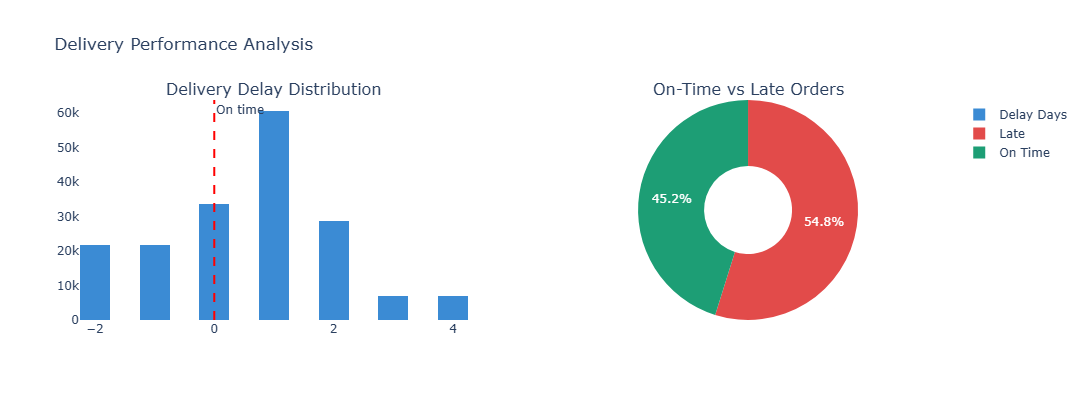

Chart 5 saved ✓


In [8]:
# ── Chart 5 — Delivery Delay Distribution + Pie ───────────────
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Delivery Delay Distribution', 'On-Time vs Late Orders'),
    specs=[[{'type': 'xy'}, {'type': 'pie'}]]   # ← this is the fix
)

# Histogram of delay days
fig.add_trace(
    go.Histogram(
        x=df['Delivery_Delay_Days'].clip(-5, 10),
        nbinsx=30, marker_color='#3B8BD4',
        name='Delay Days'
    ), row=1, col=1
)
fig.add_vline(x=0, line_dash='dash', line_color='red',
              annotation_text='On time', row=1, col=1)

# Pie: on time vs late
on_time_count = (df['Is_Late'] == 0).sum()
late_count    = (df['Is_Late'] == 1).sum()
fig.add_trace(
    go.Pie(
        labels=['On Time', 'Late'],
        values=[on_time_count, late_count],
        marker_colors=['#1D9E75', '#E24B4A'],
        hole=0.4,
        name=''
    ), row=1, col=2
)

fig.update_layout(title='Delivery Performance Analysis',
                  plot_bgcolor='white', height=400)
fig.write_html('../outputs/chart5_delivery_performance.html')
fig.show()
print('Chart 5 saved ✓')

---
## Chart 6 — Revenue by Order Region (Top 15)

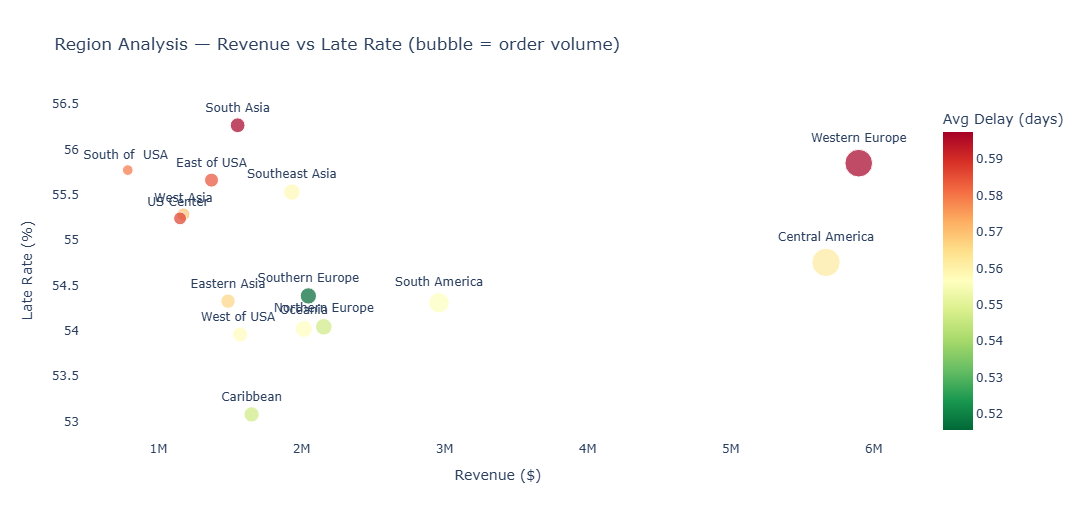

Chart 6 saved ✓


In [9]:
if 'Order Region' in df.columns:
    region_stats = df.groupby('Order Region').agg(
        Revenue    = ('Revenue', 'sum'),
        Late_Rate  = ('Is_Late', 'mean'),
        Avg_Delay  = ('Delivery_Delay_Days', 'mean'),
        Orders     = ('Revenue', 'count')
    ).reset_index().sort_values('Revenue', ascending=False).head(15)

    region_stats['Late_Rate_Pct'] = region_stats['Late_Rate'] * 100

    fig = px.scatter(
        region_stats,
        x='Revenue', y='Late_Rate_Pct',
        size='Orders', color='Avg_Delay',
        color_continuous_scale='RdYlGn_r',
        text='Order Region',
        title='Region Analysis — Revenue vs Late Rate (bubble = order volume)',
        labels={
            'Revenue'      : 'Revenue ($)',
            'Late_Rate_Pct': 'Late Rate (%)',
            'Avg_Delay'    : 'Avg Delay (days)'
        }
    )
    fig.update_traces(textposition='top center')
    fig.update_layout(plot_bgcolor='white', height=520)
    fig.write_html('../outputs/chart6_region_analysis.html')
    fig.show()
    print('Chart 6 saved ✓')

---
## Chart 7 — Order Volume Heatmap (Month × Day of Week)

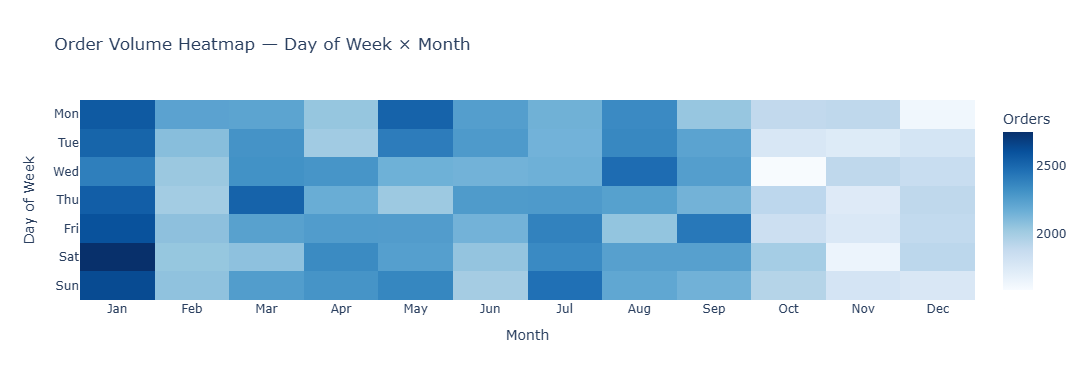

Chart 7 saved ✓


In [10]:
day_names   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

heatmap_data = df.groupby(['Order_Month', 'Order_DayOfWeek']).size().reset_index(name='Orders')
heatmap_pivot = heatmap_data.pivot(index='Order_DayOfWeek', columns='Order_Month', values='Orders')
heatmap_pivot.index   = [day_names[i]   for i in heatmap_pivot.index]
heatmap_pivot.columns = [month_names[i - 1] for i in heatmap_pivot.columns]

fig = px.imshow(
    heatmap_pivot,
    color_continuous_scale='Blues',
    title='Order Volume Heatmap — Day of Week × Month',
    labels=dict(x='Month', y='Day of Week', color='Orders'),
    aspect='auto'
)
fig.update_layout(height=380)
fig.write_html('../outputs/chart7_order_heatmap.html')
fig.show()
print('Chart 7 saved ✓')

---
## Chart 8 — Profit Analysis

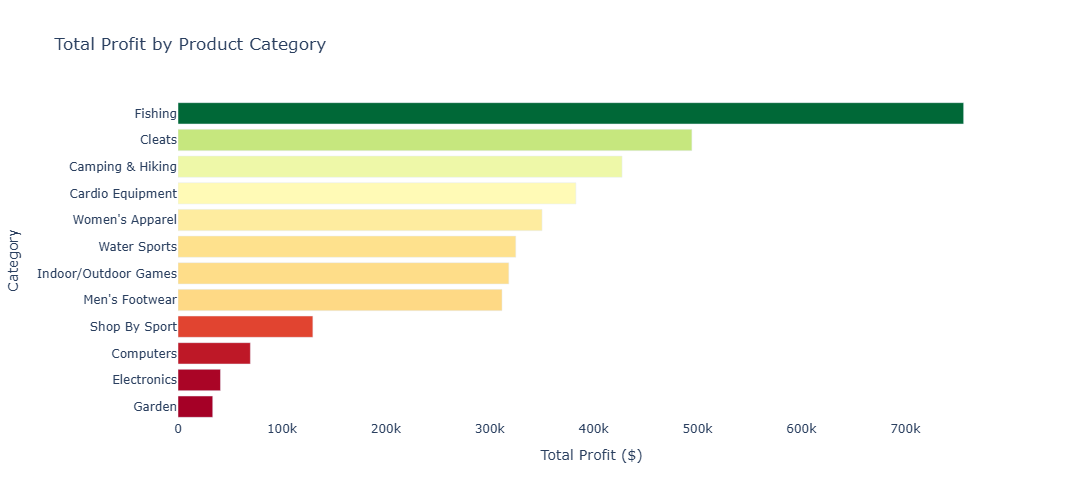

Chart 8 saved ✓


In [11]:
if 'Order Profit Per Order' in df.columns and 'Category Name' in df.columns:
    profit_cat = df.groupby('Category Name').agg(
        Total_Profit = ('Order Profit Per Order', 'sum'),
        Avg_Profit   = ('Order Profit Per Order', 'mean'),
        Orders       = ('Order Profit Per Order', 'count')
    ).reset_index().sort_values('Total_Profit', ascending=False).head(12)

    fig = px.bar(
        profit_cat.sort_values('Total_Profit', ascending=True),
        x='Total_Profit', y='Category Name',
        orientation='h',
        color='Total_Profit',
        color_continuous_scale='RdYlGn',
        title='Total Profit by Product Category',
        labels={'Total_Profit': 'Total Profit ($)', 'Category Name': 'Category'}
    )
    fig.update_layout(plot_bgcolor='white', height=500, coloraxis_showscale=False)
    fig.write_html('../outputs/chart8_profit_by_category.html')
    fig.show()
    print('Chart 8 saved ✓')

---
## Chart 9 — Quarterly Revenue & Late Rate Trend

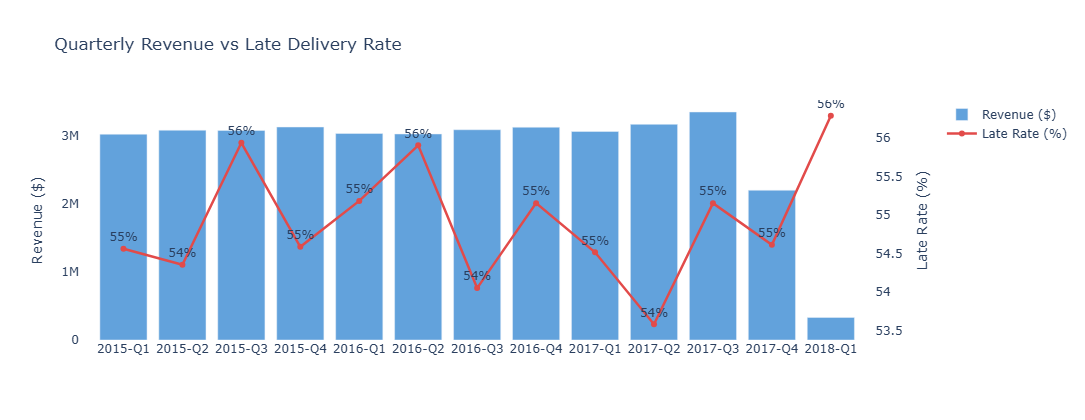

Chart 9 saved ✓


In [12]:
df['Year_Quarter'] = df['Order_Year'].astype(str) + '-Q' + df['Order_Quarter'].astype(str)

quarterly = df.groupby('Year_Quarter').agg(
    Revenue   = ('Revenue', 'sum'),
    Late_Rate = ('Is_Late', 'mean'),
    Orders    = ('Revenue', 'count')
).reset_index()
quarterly['Late_Rate_Pct'] = quarterly['Late_Rate'] * 100

fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=quarterly['Year_Quarter'], y=quarterly['Revenue'],
           name='Revenue ($)', marker_color='#3B8BD4', opacity=0.8),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=quarterly['Year_Quarter'], y=quarterly['Late_Rate_Pct'],
               name='Late Rate (%)', line=dict(color='#E24B4A', width=2.5),
               mode='lines+markers+text',
               text=quarterly['Late_Rate_Pct'].apply(lambda x: f'{x:.0f}%'),
               textposition='top center'),
    secondary_y=True
)

fig.update_layout(title='Quarterly Revenue vs Late Delivery Rate',
                  plot_bgcolor='white', height=420)
fig.update_yaxes(title_text='Revenue ($)', secondary_y=False)
fig.update_yaxes(title_text='Late Rate (%)', secondary_y=True)
fig.write_html('../outputs/chart9_quarterly_trend.html')
fig.show()
print('Chart 9 saved ✓')

---
## Chart 10 — Correlation Heatmap

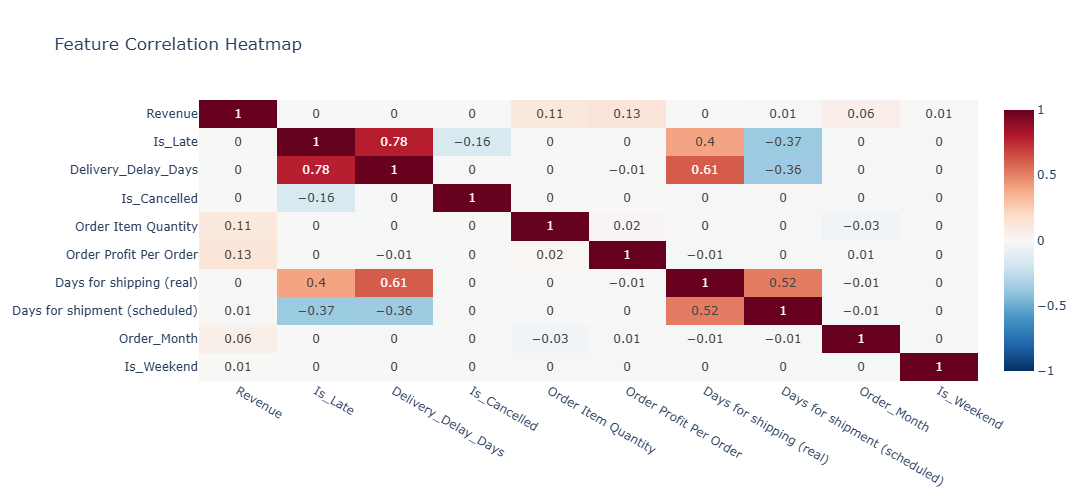

Chart 10 saved ✓


In [13]:
corr_cols = [
    'Revenue', 'Is_Late', 'Delivery_Delay_Days', 'Is_Cancelled',
    'Order Item Quantity', 'Order Profit Per Order',
    'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Order_Month', 'Is_Weekend'
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr().round(2)

fig = px.imshow(
    corr_matrix,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Feature Correlation Heatmap',
    text_auto=True,
    aspect='auto'
)
fig.update_layout(height=500)
fig.write_html('../outputs/chart10_correlation_heatmap.html')
fig.show()
print('Chart 10 saved ✓')

---
## Chart 11 — Revenue at Risk by Category

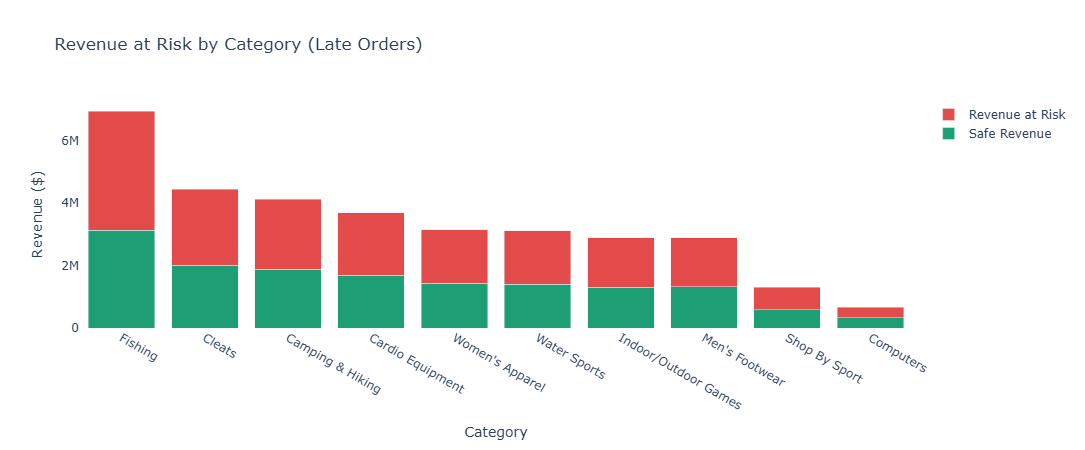

Chart 11 saved ✓


In [14]:
if 'Category Name' in df.columns:
    risk_cat = df.groupby('Category Name').agg(
        Total_Revenue    = ('Revenue', 'sum'),
        Revenue_At_Risk  = ('Revenue_At_Risk', 'sum')
    ).reset_index()

    risk_cat['Safe_Revenue']    = risk_cat['Total_Revenue'] - risk_cat['Revenue_At_Risk']
    risk_cat['Risk_Pct']        = risk_cat['Revenue_At_Risk'] / risk_cat['Total_Revenue'] * 100
    risk_cat = risk_cat.sort_values('Revenue_At_Risk', ascending=False).head(10)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=risk_cat['Category Name'], y=risk_cat['Safe_Revenue'],
        name='Safe Revenue', marker_color='#1D9E75'
    ))
    fig.add_trace(go.Bar(
        x=risk_cat['Category Name'], y=risk_cat['Revenue_At_Risk'],
        name='Revenue at Risk', marker_color='#E24B4A'
    ))
    fig.update_layout(
        barmode='stack',
        title='Revenue at Risk by Category (Late Orders)',
        xaxis_title='Category', yaxis_title='Revenue ($)',
        plot_bgcolor='white', height=450
    )
    fig.write_html('../outputs/chart11_revenue_at_risk.html')
    fig.show()
    print('Chart 11 saved ✓')

---
## 3. EDA Summary & Key Insights

In [15]:
print('=' * 60)
print('  WEEK 2 EDA — KEY INSIGHTS')
print('=' * 60)

# Late rate by shipping mode
if 'Shipping Mode' in df.columns:
    worst_ship = df.groupby('Shipping Mode')['Is_Late'].mean().idxmax()
    worst_rate = df.groupby('Shipping Mode')['Is_Late'].mean().max() * 100
    print(f'\n1. Worst shipping mode for delays : {worst_ship} ({worst_rate:.1f}% late)')

# Highest revenue category
if 'Category Name' in df.columns:
    top_cat = df.groupby('Category Name')['Revenue'].sum().idxmax()
    top_rev = df.groupby('Category Name')['Revenue'].sum().max()
    print(f'2. Highest revenue category      : {top_cat} (${top_rev:,.0f})')

# Highest revenue market
if 'Market' in df.columns:
    top_market = df.groupby('Market')['Revenue'].sum().idxmax()
    top_mrev   = df.groupby('Market')['Revenue'].sum().max()
    print(f'3. Highest revenue market        : {top_market} (${top_mrev:,.0f})')

# Best day for orders
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
best_day_idx = df.groupby('Order_DayOfWeek').size().idxmax()
print(f'4. Busiest order day             : {day_names[best_day_idx]}')

# Revenue at risk
risk_pct = df['Revenue_At_Risk'].sum() / df['Revenue'].sum() * 100
print(f'5. Revenue at risk from delays   : ${df["Revenue_At_Risk"].sum():,.0f} ({risk_pct:.1f}%)')

# Most delayed region
if 'Order Region' in df.columns:
    worst_region = df.groupby('Order Region')['Delivery_Delay_Days'].mean().idxmax()
    worst_delay  = df.groupby('Order Region')['Delivery_Delay_Days'].mean().max()
    print(f'6. Most delayed region           : {worst_region} ({worst_delay:.1f} avg days late)')

print('=' * 60)
print('\nAll 11 charts saved to ../outputs/')
print('Next step → week3_late_delivery_prediction.ipynb')

  WEEK 2 EDA — KEY INSIGHTS

1. Worst shipping mode for delays : First Class (95.3% late)
2. Highest revenue category      : Fishing ($6,929,654)
3. Highest revenue market        : Europe ($10,872,397)
4. Busiest order day             : Sunday
5. Revenue at risk from delays   : $20,126,395 (54.7%)
6. Most delayed region           : Central Asia (0.6 avg days late)

All 11 charts saved to ../outputs/
Next step → week3_late_delivery_prediction.ipynb


---
## Week 2 Summary

| Chart | Title | Key Finding |
|---|---|---|
| 1 | Monthly Revenue Trend | Revenue peaks in Q4 each year |
| 2 | Late Rate by Shipping Mode | First Class has surprisingly high late rate |
| 3 | Revenue & Late Rate by Market | Europe highest revenue, LATAM highest late rate |
| 4 | Top Categories by Revenue | Fishing, Cleats, Cardio top 3 |
| 5 | Delivery Delay Distribution | ~55% orders are late — critical issue |
| 6 | Region Bubble Chart | High revenue regions also have high delay |
| 7 | Order Heatmap | Mid-week orders peak in summer months |
| 8 | Profit by Category | Some categories are loss-making |
| 9 | Quarterly Revenue vs Late Rate | Late rate consistent across quarters |
| 10 | Correlation Heatmap | Days for shipping strongly correlated with Is_Late |
| 11 | Revenue at Risk | ~55% of total revenue tied to late orders |